In [ ]:
pip install ugot

In [1]:
from ugot import ugot
got = ugot.UGOT()
got.initialize('192.168.1.230')
print("Hello World")
got.play_audio_tts("Hello World!", 0, False)

192.168.1.230:50051
Hello World


In [1]:
# OpenCV related import
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image,display

In [ ]:
Laser1 = got.read_distance_data(21)
Laser2 = got.read_distance_data(51)

print("The value for IR1 is:",Laser1)
print("The value for IR2 is:",Laser2)

# Level 4 Term2

## Session 1

In [ ]:
my_friend1=["apple",1000,"Mars",True,["red","yellow"]]
my_friend2=("apple",1000,"Mars",True,["red","yellow"])
print(my_friend1)
print(my_friend2)
print(type(my_friend1))
print(type(my_friend2))
print(my_friend2[4][0])
print(my_friend1[:])
print(my_friend1[1:3])
print(my_friend2[::2])
print(my_friend2[::-1])

In [ ]:
my_friend3 = {
    "Name":"Jack",
    "Age":1000,
    "Birth place":"Sun",
    "Fruit":["apple","banana","orange"],
    "Color":"blue",
}
print(my_friend3)
print(my_friend3["Color"])
print(my_friend3.keys())
print(my_friend3.values())
print(my_friend3.items())
my_friend3["Name"]="Tom"
print(my_friend3)

1. OpenCV

In [ ]:
pip install opencv-python

In [ ]:
pip install matplotlib

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image,display

2. display image and inspect its data

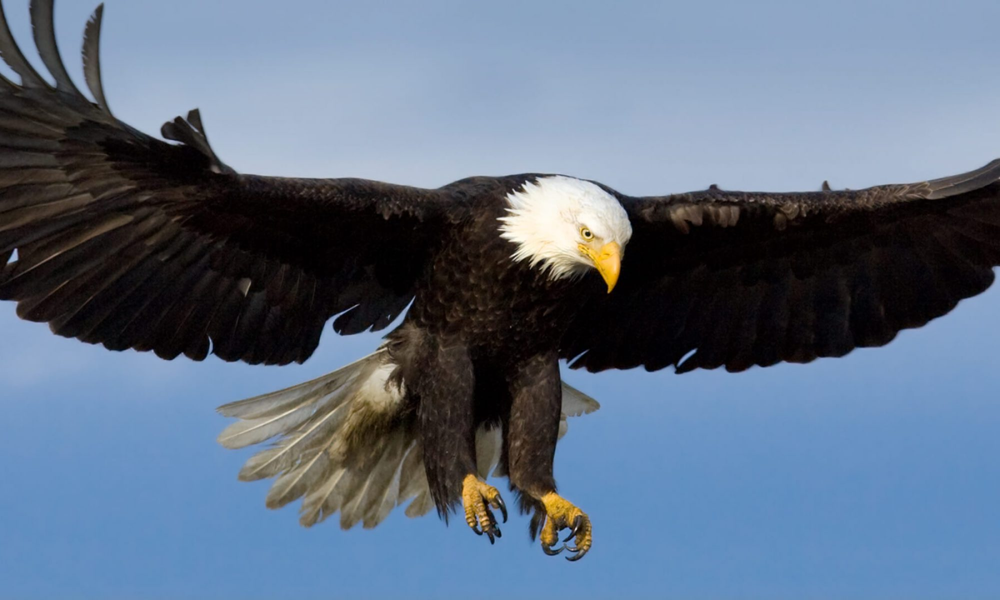

In [11]:
Image("eagle.jpg")

In [12]:
eagle=cv2.imread("eagle.jpg")
print("Loaded:",eagle is not None)
if eagle is not None:
    print("Shape(H,W,C):",eagle.shape)
    print("dtype:",eagle.dtype)
    print("Top-left pixel(B,G,R):",eagle[0,0])

Loaded: True
Shape(H,W,C): (1200, 2000, 3)
dtype: uint8
Top-left pixel(B,G,R): [39 39 33]


## Session 2

1. Array

In [ ]:
arrays1 = [1,2,3,4,5,6]
print(arrays1)
print(type(arrays1))

In [ ]:
arrays1 = [1,2,3,4,5,6] # arrays demands the same data type itmes
list1 = [1,"apple",True,["red","blue"]]
print(type(arrays1))
print(type(list1))

2. Arrays in Numpy

In [ ]:
import numpy as np
# 1D array
array1d = np.array([1,2,3,4,5,6])
print(f"1D Arrays:{array1d}")
print(f"Shape:{array1d.shape}")
print(type(array1d))

In [ ]:
# 2D array
array2d = np.array([[1,2,3],
                    [4,5,6]])
print(f"2D Arrays:\n{array2d}")
print(f"Shape:{array2d.shape}")
print(type(array2d))

In [ ]:
# 3D array
array3d=np.array([[[255,0,0],[0,255,0],[0,0,255]],
                  [[0,0,255],[0,255,0],[255,0,0]]])
print(f"3D Arrays:\n{array3d}")
print(f"Shape:{array3d.shape}")
print(type(array3d))

In [ ]:
Image("Array.png")

3. UGOT image display

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

# Step 1: turn on the camera
got.open_camera()
print("The camera is on.")

# Step 2: get the raw data
picture = got.read_camera_data()
print(f"The raw data:{picture}")
print(f"Data type:{type(picture)}")

# Step 3: unpack the raw data, bytes to 1D array
picture  = np.frombuffer(picture,np.uint8)
print(f"The data:{picture}")
print(f"Shape:{picture.shape}")
print(f"Data type:{type(picture)}")

# Step 4: 1D array to 3D array
picture = cv2.imdecode(picture,cv2.IMREAD_COLOR)
print(f"The data:{picture}")
print(f"Shape:{picture.shape}")
print(f"Data type:{type(picture)}")

# Step 5: pack the 3D array for Jupyter
ok,picture_jpg = cv2.imencode(".jpg",picture)
print(f"The data:{picture}")
print(f"Shape:{picture.shape}")
print(f"Data type:{type(picture)}")

# Step 6: show the image on the screen
display(Image(picture_jpg.tobytes()))

## Session 3

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
picture = got.read_camera_data()
picture  = np.frombuffer(picture,np.uint8)
picture = cv2.imdecode(picture,cv2.IMREAD_COLOR)
ok,picture_jpg = cv2.imencode(".jpg",picture)
display(Image(picture_jpg.tobytes()))

In [ ]:
Image("Robot camera to image-2.png")

1. change photos to video

In [ ]:
import numpy as np
import cv2
from IPython.display import clear_output,display, Image

got.open_camera()
print("The camera is on.")

for i in range(100):
    picture = got.read_camera_data()

    if picture is None:
        continue

    picture  = np.frombuffer(picture,np.uint8)
    picture = cv2.imdecode(picture,cv2.IMREAD_COLOR)
    ok,picture_jpg = cv2.imencode(".jpg",picture)
    display(Image(picture_jpg.tobytes()))
    clear_output(True)

In [ ]:
Laser1 = got.read_distance_data(21)
Laser2 = got.read_distance_data(51)
print(Laser1)
print(Laser2)

## Session 4

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
picture = got.read_camera_data()
picture  = np.frombuffer(picture,np.uint8)
picture = cv2.imdecode(picture,cv2.IMREAD_COLOR)
ok,picture_jpg = cv2.imencode(".jpg",picture)
display(Image(picture_jpg.tobytes()))

1. Motion detection robot

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
print("The camera is on.")

while True:
    Laser1 = got.read_distance_data(21)
    picture = got.read_camera_data()

    if Laser1>50:
        got.show_light_rgb_effect(0,255,0,3)
        time.sleep(0.1)
    
    else:
        if picture is None:
            print("No data founded")
            continue
        
        picture  = np.frombuffer(picture,np.uint8)
        picture = cv2.imdecode(picture,cv2.IMREAD_COLOR)
        ok,picture_jpg = cv2.imencode(".jpg",picture)
        display(Image(picture_jpg.tobytes()))
        got.show_light_rgb_effect(255,0,0,3)
        time.sleep(2)
        got.turn_off_lights()
        got.play_audio_tts("Gotcha, ha ha ha", 0, False)
        break


2. Spin robot patrol

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
print("The camera is on.")

while True:
    Laser1 = got.read_distance_data(21)
    picture = got.read_camera_data()

    if Laser1>50:
        got.mecanum_turn_speed(2,20)
        got.show_light_rgb_effect(0,255,0,3)
        time.sleep(0.1)
    
    else:
        if picture is None:
            print("No data founded")
            continue
        
        got.mecanum_stop()
        picture  = np.frombuffer(picture,np.uint8)
        picture = cv2.imdecode(picture,cv2.IMREAD_COLOR)
        ok,picture_jpg = cv2.imencode(".jpg",picture)
        display(Image(picture_jpg.tobytes()))
        got.show_light_rgb_effect(255,0,0,3)
        time.sleep(2)
        got.turn_off_lights()
        got.play_audio_tts("Gotcha, ha ha ha", 0, False)
        break

3.Sweeper robot patrol

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

# Step1: create the photo taking function
def take_photo():
    picture = got.read_camera_data()
    if picture is None:
        print("No data founded")
        return
    
    got.mecanum_stop()
    picture  = np.frombuffer(picture,np.uint8)
    picture = cv2.imdecode(picture,cv2.IMREAD_COLOR)
    ok,picture_jpg = cv2.imencode(".jpg",picture)
    display(Image(picture_jpg.tobytes()))
    got.show_light_rgb_effect(255,0,0,3)
    time.sleep(2)
    got.turn_off_lights()
    got.play_audio_tts("Gotcha, ha ha ha", 0, False)

# step2: start sweeping
got.open_camera()
print("The camera is on.")

while True:
    # sweep from left to right
    for i in range(16): 
        Laser1 = got.read_distance_data(21)

        if Laser1>50:
            got.mecanum_turn_speed(2,20)
            got.show_light_rgb_effect(0,255,0,3)
            time.sleep(0.5)
        else:
            got.mecanum_stop()
            take_photo()
            break
    if Laser1<50:
        break
    # sweep from right to left
    for i in range(16): 
        Laser1 = got.read_distance_data(21)

        if Laser1>50:
            got.mecanum_turn_speed(3,20)
            got.show_light_rgb_effect(0,255,0,3)
            time.sleep(0.5)
        else:
            got.mecanum_stop()
            take_photo()
            break
    if Laser1<50:
        break

got.mecanum_stop()
print("Mission completed.")

## Session 5

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
picture = got.read_camera_data()
picture  = np.frombuffer(picture,np.uint8)
picture = cv2.imdecode(picture,cv2.IMREAD_COLOR)
ok,picture_jpg = cv2.imencode(".jpg",picture)
display(Image(picture_jpg.tobytes()))

1. BGR to HSV

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
picture = got.read_camera_data()
if picture is None:
    raise Exception("No camera data found.")

picture  = np.frombuffer(picture,np.uint8)
picture_bgr = cv2.imdecode(picture,cv2.IMREAD_COLOR)
if picture_bgr is None:
    raise Exception("Imdecode failed, please check the camera stream or data.")

# Convert BGR to HSV
picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)

ok,picture_hsv = cv2.imencode(".jpg",picture_hsv)
display(Image(picture_hsv.tobytes()))

2. Red color detection

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

# Open the camera and get data
got.open_camera()
picture = got.read_camera_data()
if picture is None:
    raise Exception("No camera data found.")

#Decode the picture
picture  = np.frombuffer(picture,np.uint8)
picture_bgr = cv2.imdecode(picture,cv2.IMREAD_COLOR)
if picture_bgr is None:
    raise Exception("Imdecode failed, please check the camera stream or data.")

# Convert BGR to HSV
picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)

# Detect the red color
lower_red = np.array([20,80,80])
upper_red = np.array([180,255,255])

# create a mask-red only pixel
mask = cv2.inRange(picture_hsv,lower_red,upper_red)

# Show the black-white image
ok,mask = cv2.imencode(".jpg",mask)
display(Image(mask.tobytes()))

In [ ]:
Image("Color wheel.png")

In [ ]:
Image("BGR2HSV.png")

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

# Open the camera and get data
got.open_camera()
picture = got.read_camera_data()
if picture is None:
    raise Exception("No camera data found.")

#Decode the picture
picture  = np.frombuffer(picture,np.uint8)
picture_bgr = cv2.imdecode(picture,cv2.IMREAD_COLOR)
if picture_bgr is None:
    raise Exception("Imdecode failed, please check the camera stream or data.")

# Convert BGR to HSV
picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)

# Detect the red color
lower_yellow = np.array([20,0,0])
upper_yellow = np.array([35,255,255])

# create a mask-red only pixel
mask = cv2.inRange(picture_hsv,lower_yellow,upper_yellow)

# Show the black-white image
ok,mask = cv2.imencode(".jpg",mask)
display(Image(mask.tobytes()))

## Session 6

1. Yellow only detection

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

# Open the camera and get data
got.open_camera()
picture_raw = got.read_camera_data()
if picture_raw is None:
    raise Exception("No camera data found.")

#Decode the picture
picture_1D  = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)
if picture_bgr is None:
    raise Exception("Imdecode failed, please check the camera stream or data.")

# Convert BGR to HSV
picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)

# Detect the yellow color
lower_yellow = np.array([25,160,160])
upper_yellow = np.array([60,225,225])

# create a mask-yellow only pixel
mask = cv2.inRange(picture_hsv,lower_yellow,upper_yellow)

# Show the black-white image
ok,mask = cv2.imencode(".jpg",mask)
display(Image(mask.tobytes()))

2. Yellow only image show

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

# Open the camera and get data
got.open_camera()
picture = got.read_camera_data()
if picture is None:
    raise Exception("No camera data found.")

#Decode the picture
picture  = np.frombuffer(picture,np.uint8)
picture_bgr = cv2.imdecode(picture,cv2.IMREAD_COLOR)
if picture_bgr is None:
    raise Exception("Imdecode failed, please check the camera stream or data.")

# Convert BGR to HSV
picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)

# Detect the yellow color
lower_yellow = np.array([25,150,150])
upper_yellow = np.array([60,225,225])

# create a mask-yellow only pixel
mask = cv2.inRange(picture_hsv,lower_yellow,upper_yellow)

# Show the yellow image
yellow_only = cv2.bitwise_and(picture_bgr,picture_bgr,mask=mask)

# Show the yellow only image
ok,yellow_only = cv2.imencode(".jpg",yellow_only)
display(Image(yellow_only.tobytes()))

In [ ]:
Image("Yellow only.png")

3. Bounding box

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

# Open the camera and get data
got.open_camera()
picture = got.read_camera_data()
if picture is None:
    raise Exception("No camera data found.")

#Decode the picture
picture  = np.frombuffer(picture,np.uint8)
picture_bgr = cv2.imdecode(picture,cv2.IMREAD_COLOR)
if picture_bgr is None:
    raise Exception("Imdecode failed, please check the camera stream or data.")

# Convert BGR to HSV
picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)

# Detect the yellow color
lower_yellow = np.array([20,100,100])
upper_yellow = np.array([60,225,255])

# create a mask-yellow only pixel
mask = cv2.inRange(picture_hsv,lower_yellow,upper_yellow)

# Find contours(outlines of the white area in the mask)
contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

#Loop through contours and draw bounding boxes
for contour in contours:
    area = cv2.contourArea(contour)
    if area>500:
        x,y,w,h=cv2.boundingRect(contour)
        cv2.rectangle(picture_bgr,(x,y),(x+w,y+h),(0,255,0),2)

# Show the yellow only image with bounding box
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
display(Image(picture_jpg.tobytes()))

## Session 7

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
print("The camera is on.")
picture_raw = got.read_camera_data()
picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
display(Image(picture_jpg.tobytes()))

1. UGOT camera color picker

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
print("The camera is on.")
picture_raw = got.read_camera_data()
picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)

# get the picture size
height = picture_hsv.shape[0]
width =picture_hsv.shape[1]

#find the center point
center_x = width // 2
center_y = height // 2

# read the HSV values, show it with the command: image[y,x] (row first, then column)
h = picture_hsv[center_y,center_x,0]  # H=hue(color)
s = picture_hsv[center_y,center_x,1]  # S=saturation(how vivid)
v = picture_hsv[center_y,center_x,2]  # V=value(brightness)

print(f"H = {h}")
print(f"S = {s}")
print(f"V = {v}")

# draw a small circle at the center of the camera
cv2.circle(picture_bgr,(center_x,center_y),10,(0,255,0),2)

# show the image with the circle
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
display(Image(picture_jpg.tobytes()))

2. bounding box with video

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
print("The camera is on.")
picture_raw = got.read_camera_data()
if picture_raw is None:
    raise Exception("No raw.")

picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
if picture_bgr is None:
    raise Exception("No bgr.")

# handle is for live updates in Jupyter
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
handle = display(Image(picture_jpg.tobytes()),display_id= True)

# Detect the color
lower_color = np.array([80,200,100])
upper_color = np.array([120,255,200])

start_time = time.time()
duration = 10

while time.time() - start_time< duration:
    picture_raw = got.read_camera_data()
    if picture_raw is None:
        continue

    picture_1D = np.frombuffer(picture_raw,np.uint8)
    picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
    if picture_bgr is None:
        continue

    picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(picture_hsv,lower_color,upper_color)
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        area = cv2.contourArea(contour)
        if area>1000:
            x,y,w,h=cv2.boundingRect(contour)
            center_x = x+ w// 2
            # draw a bounding box
            cv2.rectangle(picture_bgr,(x,y),(x+w,y+h),(0,255,0),2)
            # draw a center point
            cv2.circle(picture_bgr,(center_x,y+h//2),5,(255,0,0),-1)
            # show x,y,w,h and center
            text= f"cx:{center_x},w:{w},h:{h}"
            text_y = max(30,y-10)
            cv2.putText(picture_bgr,text,(x,text_y),cv2.FONT_HERSHEY_SIMPLEX,0.55,(0,255,0),2)
    #update live video
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
    if ok:
        handle.update(Image(data=picture_jpg.tobytes()))
        
    time.sleep(0.01)

## Session 8

1. vision marker recognition and approach

In [ ]:
# import libraries
import time
import numpy as np
import cv2
from IPython.display import display, Image

# create color range
lower_color = np.array([80,200,100])
upper_color = np.array([120,255,200])

# function 1: get the bgr image
def picture_bgr():
    picture_raw = got.read_camera_data()
    if picture_raw is None:
        return None
    return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

# function 2: find color and return x,y,w,h
def find_yellow(frame):
    mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    return cv2.boundingRect(max(contours,key=cv2.contourArea))

# function 3: UGOT move and draw the bounding box
def move_and_draw(frame,x,y,w,h):
    center_x = x + w//2
    if w> 280:    # close enough, stop
        got.mecanum_stop()
        return True
    elif center_x < 280:
        got.mecanum_move_xyz(-10,10,0)
    elif center_x > 360:
        got.mecanum_move_xyz(10,10,0)
    else:
        got.mecanum_move_xyz(0,10,0)
    
    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
    cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
    cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

# main program
got.open_camera()
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
handle = display(Image(picture_jpg.tobytes()),display_id = True)

while True:
    frame = picture_bgr()
    if frame is None:
        continue

    result = find_yellow(frame)
    if result:
        if move_and_draw(frame,*result):  # close enough and stop
            break
    else:
        got.mecanum_stop()
    
    ok,picture_jpg = cv2.imencode(".jpg",frame)
    if ok:
        handle.update(Image(picture_jpg.tobytes()))
    
    time.sleep(0.05)


## Session 9

In [ ]:
# practice
import numpy as np
import cv2
from IPython.display import display, Image

picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
picture_1D = np.frombuffer(picture_raw,np.uint8)
print("The camera is on.")
picture_hsv = cv2.cvtColor(picture_bgr, cv2.COLOR_BGR2HSV)
got.open_camera()
picture_hsv = cv2.cvtColor(picture_bgr, cv2.COLOR_BGR2HSV)
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
display(Image(picture_jpg.tobytes()))
picture_raw = got.read_camera_data()


1. function library

In [ ]:
def color_rotate_centralizing():
    # import libraries
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # create color range
    lower_color = np.array([80,200,100])
    upper_color = np.array([120,255,200])

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

    # function 2: find color and return x,y,w,h
    def find_color(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None

        for contour in contours:  # ignore the background noise and find the correct bounding box
            area = cv2.contourArea(contour)
            if area>1000:
                return cv2.boundingRect(contour)

    # function 3: UGOT rotate and draw the bounding box
    def rotate_and_draw(frame,x,y,w,h):
        center_x = x + w//2
        
        if center_x >300:  # color is centralized, stop
            got.mecanum_stop()
            return True
        else:
            got.mecanum_move_xyz(0,0,20)  # rotate anti-clockwise to find the vision marker
        
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

    # main program
    got.open_camera()
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(picture_jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_color(frame)
        if result:
            if rotate_and_draw(frame,*result):  # centralized and stop
                break
        else:
            got.mecanum_move_xyz(0,0,20)
        
        ok,picture_jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))
        
        time.sleep(0.05)

In [ ]:
def color_centralizing_approaching():
    # import libraries
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # create color range
    lower_color = np.array([80,200,100])
    upper_color = np.array([120,255,200])

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

    # function 2: find color and return x,y,w,h
    def find_yellow(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours,key=cv2.contourArea))

    # function 3: UGOT move and draw the bounding box
    def move_and_draw(frame,x,y,w,h):
        center_x = x + w//2
        if w> 280:    # close enough, stop
            got.mecanum_stop()
            return True
        elif center_x < 280:
            got.mecanum_move_xyz(-10,10,0)
        elif center_x > 360:
            got.mecanum_move_xyz(10,10,0)
        else:
            got.mecanum_move_xyz(0,10,0)
        
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

    # main program
    got.open_camera()
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(picture_jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_yellow(frame)
        if result:
            if move_and_draw(frame,*result):  # close enough and stop
                break
        else:
            got.mecanum_stop()
        
        ok,picture_jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))
        
        time.sleep(0.05)

In [ ]:
color_centralizing_approaching()

## Session 10

In [ ]:
def color_centralizing_approaching():
    # import libraries
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # create color range
    lower_color = np.array([80,200,100])
    upper_color = np.array([120,255,200])

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

    # function 2: find color and return x,y,w,h
    def find_color(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours,key=cv2.contourArea))

    # function 3: UGOT move and draw the bounding box
    def move_and_draw(frame,x,y,w,h):
        center_x = x + w//2
        if w> 280:    # close enough, stop
            got.mecanum_stop()
            return True
        elif center_x < 280:
            got.mecanum_move_xyz(-10,10,0)
        elif center_x > 360:
            got.mecanum_move_xyz(10,10,0)
        else:
            got.mecanum_move_xyz(0,10,0)
        
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

    # main program
    got.open_camera()
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(picture_jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_color(frame)
        if result:
            if move_and_draw(frame,*result):  # close enough and stop
                break
        else:
            got.mecanum_stop()
        
        ok,picture_jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))
        
        time.sleep(0.05)


In [ ]:
def color_rotate_centralizing():
    # import libraries
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # create color range
    lower_color = np.array([80,200,100])
    upper_color = np.array([120,255,200])

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

    # function 2: find color and return x,y,w,h
    def find_color(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None

        for contour in contours:  # ignore the background noise and find the correct bounding box
            area = cv2.contourArea(contour)
            if area>1000:
                return cv2.boundingRect(contour)

    # function 3: UGOT rotate and draw the bounding box
    def rotate_and_draw(frame,x,y,w,h):
        center_x = x + w//2
        
        if center_x >300:  # color is centralized, stop
            got.mecanum_stop()
            return True
        else:
            got.mecanum_move_xyz(0,0,20)  # rotate anti-clockwise to find the vision marker
        
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

    # main program
    got.open_camera()
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(picture_jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_color(frame)
        if result:
            if rotate_and_draw(frame,*result):  # centralized and stop
                break
        else:
            got.mecanum_move_xyz(0,0,20)
        
        ok,picture_jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))
        
        time.sleep(0.05)

In [ ]:
for i in range(4):
    color_rotate_centralizing()
    color_centralizing_approaching()
    got.mecanum_turn_speed_times(2,30,70,2)

got.play_audio_tts("Good job, mission completed!", 0, False)

# Level4 Term 3

## Session 2

1. PID control

In [ ]:
while True:
    Laser1 = got.read_distance_data(21)
    if Laser1 >15:
        got.mecanum_move_speed(0,20)
    else:
        got.mecanum_stop()
        break

In [ ]:
# deceleration program
Laser1 = got.read_distance_data(21)

while Laser1>10:
    Laser1 = got.read_distance_data(21)
    speed = Laser1

    if Laser1>50:
        got.mecanum_move_speed(0,50)
    else:
        got.mecanum_move_speed(0,int(speed))
        print(f"The current speed is {speed} cm/s.")
got.mecanum_stop()
print("It's too close, let's stop.")


In [ ]:
Image("PID.png")

In [ ]:
# proportional control

safe_distance = 10
kp = 0.8

while True:
    current_distance = got.read_distance_data(21)

    error = current_distance - safe_distance
    print(f"The error is :{error}")

    if abs(error) <1:
        got.mecanum_stop()
        break
    
    speed = int(kp * error)
    speed = max(min(speed,50),-20)
    print(f"The speed is: {speed} ")
    got.mecanum_move_xyz(0,speed,0)

## Session 3

1. proportional control

In [ ]:
# deceleration program
Laser1 = got.read_distance_data(21)

while Laser1>10:
    Laser1 = got.read_distance_data(21)
    speed = Laser1

    if Laser1>50:
        got.mecanum_move_speed(0,50)
    else:
        got.mecanum_move_speed(0,int(speed))
        print(f"The current speed is {speed} cm/s.")
got.mecanum_stop()
print("It's too close, let's stop.")


In [ ]:
# proportational control
import time
safe_distance = 10
Kp = 0.8

while True:
    current_distance = got.read_distance_data(21)
    error = current_distance- safe_distance
    print(f"The error value is : {error} cm.")

    if abs(error) < 1:
        got.mecanum_stop()
        break

    speed = Kp * error
    print(f"The speed is: {speed} cm/s.")
    got.mecanum_move_xyz(0,int(speed),0)
    time.sleep(0.05)

In [ ]:
# proportational + integral control
import time
safe_distance = 10
Kp = 0.8
Ki = 0.1

total_error = 0

while True:
    current_distance = got.read_distance_data(21)
    error = current_distance- safe_distance
    print(f"The error value is : {error} cm.")

    if abs(error) < 1:
        got.mecanum_stop() 
        break

    total_error += error
    total_error = max(min(total_error,100),-100)
    print(f"The total error is :{total_error}.")

    speed = Kp * error + Ki* total_error
    speed = max(min(speed,50),-50)
    print(f"The speed is: {speed} cm/s.")
    got.mecanum_move_xyz(0,int(speed),0)
    time.sleep(0.05)

## Session 4

1. PID control

In [ ]:
# Proportional + Integral + Derivative Control

import time
safe_distance = 10
Kp = 0.8
Ki = 0.05
Kd = 0.2

total_error = 0
current_distance = got.read_distance_data(21)
error = current_distance - safe_distance
previous_error = error

while True:
    current_distance = got.read_distance_data(21)
    error = current_distance - safe_distance
    previous_error = error
    print(f"The error value is : {error} cm.")

    if abs(error) < 1:
        got.mecanum_stop() 
        break

    total_error += error
    total_error = max(min(total_error,100),-100)
    print(f"The total error is :{total_error}.")
    derivative = error - previous_error
    print(f"The derivative is :{derivative}.")

    speed = Kp * error + Ki*total_error + Kd*derivative
    speed = max(min(speed,50),-50)
    print(f"The speed is: {speed} cm/s.")

    previous_error = error

    got.mecanum_move_xyz(0,int(speed),0)
    time.sleep(0.05)

2. color ball detection

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
print("The camera is on.")
picture_raw = got.read_camera_data()
picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)

# get the picture size
height = picture_hsv.shape[0]
width =picture_hsv.shape[1]

#find the center point
center_x = width // 2
center_y = height // 2

# read the HSV values, show it with the command: image[y,x] (row first, then column)
h = picture_hsv[center_y,center_x,0]  # H=hue(color)
s = picture_hsv[center_y,center_x,1]  # S=saturation(how vivid)
v = picture_hsv[center_y,center_x,2]  # V=value(brightness)

print(f"H = {h}")
print(f"S = {s}")
print(f"V = {v}")

# draw a small circle at the center of the camera
cv2.circle(picture_bgr,(center_x,center_y),10,(0,255,0),2)

# show the image with the circle
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
display(Image(picture_jpg.tobytes()))

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
print("The camera is on.")
picture_raw = got.read_camera_data()
if picture_raw is None:
    raise Exception("No raw.")

picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
if picture_bgr is None:
    raise Exception("No bgr.")

# handle is for live updates in Jupyter
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
handle = display(Image(picture_jpg.tobytes()),display_id= True)

# Detect the color
lower_color = np.array([80,200,90])
upper_color = np.array([150,255,180])

start_time = time.time()
duration = 10

while time.time() - start_time< duration:
    picture_raw = got.read_camera_data()
    if picture_raw is None:
        continue

    picture_1D = np.frombuffer(picture_raw,np.uint8)
    picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
    if picture_bgr is None:
        continue

    picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(picture_hsv,lower_color,upper_color)
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        area = cv2.contourArea(contour)
        if area>1000:
            x,y,w,h=cv2.boundingRect(contour)
            center_x = x+ w// 2
            # draw a bounding box
            cv2.rectangle(picture_bgr,(x,y),(x+w,y+h),(0,255,0),2)
            # draw a center point
            cv2.circle(picture_bgr,(center_x,y+h//2),5,(255,0,0),-1)
            # show x,y,w,h and center
            text= f"cx:{center_x},w:{w},h:{h}"
            text_y = max(30,y-10)
            cv2.putText(picture_bgr,text,(x,text_y),cv2.FONT_HERSHEY_SIMPLEX,0.55,(0,255,0),2)
    #update live video
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
    if ok:
        handle.update(Image(data=picture_jpg.tobytes()))
        
    time.sleep(0.01)

In [ ]:
def color_ball_centralizing_approaching():
    # import libraries
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # create color range
    lower_color = np.array([80,200,90])
    upper_color = np.array([150,255,180])

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

    # function 2: find color and return x,y,w,h
    def find_yellow(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours,key=cv2.contourArea))

    # function 3: UGOT move and draw the bounding box
    def move_and_draw(frame,x,y,w,h):
        center_x = x + w//2
        if w> 150:    # close enough, stop
            got.mecanum_stop()
            return True
        elif center_x < 280:
            got.mecanum_move_xyz(-10,10,0)
        elif center_x > 360:
            got.mecanum_move_xyz(10,10,0)
        else:
            got.mecanum_move_xyz(0,10,0)
        
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

    # main program
    got.open_camera()
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(picture_jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_yellow(frame)
        if result:
            if move_and_draw(frame,*result):  # close enough and stop
                break
        else:
            got.mecanum_stop()
        
        ok,picture_jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))
        
        time.sleep(0.05)

In [ ]:
color_ball_centralizing_approaching()

## Session 5

1. bounding box with video

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
print("The camera is on.")
picture_raw = got.read_camera_data()
if picture_raw is None:
    raise Exception("No raw.")

picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
if picture_bgr is None:
    raise Exception("No bgr.")

# handle is for live updates in Jupyter
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
handle = display(Image(picture_jpg.tobytes()),display_id= True)

# Detect the color
lower_color = np.array([130,210,140])
upper_color = np.array([210,255,225])

start_time = time.time()
duration = 10

while time.time() - start_time< duration:
    picture_raw = got.read_camera_data()
    if picture_raw is None:
        continue

    picture_1D = np.frombuffer(picture_raw,np.uint8)
    picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
    if picture_bgr is None:
        continue

    picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(picture_hsv,lower_color,upper_color)
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        area = cv2.contourArea(contour)
        if area>500:
            x,y,w,h=cv2.boundingRect(contour)
            center_x = x+ w// 2
            # draw a bounding box
            cv2.rectangle(picture_bgr,(x,y),(x+w,y+h),(0,255,0),2)
            # draw a center point
            cv2.circle(picture_bgr,(center_x,y+h//2),5,(255,0,0),-1)
            # show x,y,w,h and center
            text= f"cx:{center_x},w:{w},h:{h}"
            text_y = max(30,y-10)
            cv2.putText(picture_bgr,text,(x,text_y),cv2.FONT_HERSHEY_SIMPLEX,0.55,(0,255,0),2)
    #update live video
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
    if ok:
        handle.update(Image(data=picture_jpg.tobytes()))
        
    time.sleep(0.01)

2. color ball centralization and approaching

In [ ]:
def color_ball_centralizing_approaching():
    # import libraries
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # create color range
    lower_color = np.array([75,210,110])
    upper_color = np.array([155,255,190])

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

    # function 2: find color and return x,y,w,h
    def find_yellow(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours,key=cv2.contourArea))

    # function 3: UGOT move and draw the bounding box
    def move_and_draw(frame,x,y,w,h):
        center_x = x + w//2
        if w> 70:    # close enough, stop
            got.mecanum_stop()
            return True
        elif center_x < 280:
            got.mecanum_move_xyz(-10,10,0)
        elif center_x > 360:
            got.mecanum_move_xyz(10,10,0)
        else:
            got.mecanum_move_xyz(0,10,0)
        
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

    # main program
    got.open_camera()
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(picture_jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_yellow(frame)
        if result:
            if move_and_draw(frame,*result):  # close enough and stop
                break
        else:
            got.mecanum_stop()
        
        ok,picture_jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))
        
        time.sleep(0.05)

In [ ]:
import time
color_ball_centralizing_approaching()
got.mecanum_move_speed_times(0,50,20,1)

start_time = time.time()

while time.time() - start_time < 10:
    got.mecanum_move_speed(0,30)
    color_ball_centralizing_approaching()

got.mecanum_stop()
print("Game over!")

## Session 6

1. color ball centralizing approaching PID control

In [ ]:
def color_ball_centralizing_approaching_Kp():
    # import libraries
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # create color range
    lower_color = np.array([140,190,160])
    upper_color = np.array([220,255,250])

    # Kp values
    Kp_x = 0.08
    Kp_y = 0.3

    frame_center = 320
    target_w = 120
    dead_zone_x = 20
    dead_zone_y = 5

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

    # function 2: find color and return x,y,w,h
    def find_ball(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours,key=cv2.contourArea))

    # function 3: Kp move and draw the bounding box
    def move_and_draw(frame,x,y,w,h):
        center_x = x + w//2

        # calculate errors
        error_x = center_x - frame_center
        error_y = target_w - w

        # check: close enough and stop
        if abs(error_x) < dead_zone_x and abs(error_y) <dead_zone_y:
            got.mecanum_stop()
            return True
        
        #Kp output
        speed_x = int(Kp_x * error_x)
        speed_y = int(Kp_y * error_y)

        # clamp to safe speed range
        speed_x = max(min(speed_x, 25),-25)
        speed_y = max(min(speed_y, 25),-25)

        got.mecanum_move_xyz(speed_x, speed_y,0)

        #draw bounding box and debug info        
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"cx:{center_x},ex:{error_x},ey:{error_y}w:{w}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

    # main program
    got.open_camera()
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(picture_jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_ball(frame)
        if result:
            if move_and_draw(frame,*result):  # close enough and stop
                break
        else:
            got.mecanum_stop()
        
        ok,picture_jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))
        
        time.sleep(0.05)

In [ ]:
import time
color_ball_centralizing_approaching_Kp()
time.sleep(1)
got.mecanum_move_speed_times(0,5,8,1)
time.sleep(1)
got.mecanum_turn_speed_times(2,20,180,2)

## Session 7

1. Color picker

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
print("The camera is on.")
picture_raw = got.read_camera_data()
picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)

# get the picture size
height = picture_hsv.shape[0]
width =picture_hsv.shape[1]

#find the center point
center_x = width // 2
center_y = height // 2

# read the HSV values, show it with the command: image[y,x] (row first, then column)
h = picture_hsv[center_y,center_x,0]  # H=hue(color)
s = picture_hsv[center_y,center_x,1]  # S=saturation(how vivid)
v = picture_hsv[center_y,center_x,2]  # V=value(brightness)

print(f"H = {h}")
print(f"S = {s}")
print(f"V = {v}")

# draw a small circle at the center of the camera
cv2.circle(picture_bgr,(center_x,center_y),10,(0,255,0),2)

# show the image with the circle
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
display(Image(picture_jpg.tobytes()))

2. face recognition

In [ ]:
import time
got.load_models(["face_recognition"])
got.face_recognition_add_name("Arjun")
time.sleep(2)

In [ ]:
import time
face_info = got.get_face_recognition_total_info()
name = face_info[0][0]
face_x = face_info[0][1]
face_width = face_info[0][4]
for i in range(4):
    face_info = got.get_face_recognition_total_info()
    print(f"Name is:{name}, x coordinate is:{face_x}, width is :{face_width}.")
    time.sleep(2)


In [ ]:
got.face_recognition_delete_name("Arjun")

In [ ]:
while True:
    face_info = got.get_face_recognition_total_info()
    if not face_info:
        got.mecanum_move_xyz(0,0,25)
    else:
        got.mecanum_stop()
        break

while True:
    face_info = got.get_face_recognition_total_info()
    face_x = face_info[0][1]
    if face_x <300:
        got.mecanum_move_xyz(0,0,25)
    else:
        got.mecanum_stop()
        break

In [ ]:
while True:
    face_info = got.get_face_recognition_total_info()
    if not face_info:
        got.mecanum_move_xyz(0,0,25)
    elif face_info[0][1]<300:
        got.mecanum_move_xyz(0,0,25)
    else:
        got.mecanum_stop()
        break

## Session 8/9

1. blue cube recognition

In [ ]:
def blue_cube_centralizing_approaching_Kp():
    # import libraries
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # create color range
    lower_color = np.array([60,190,100])
    upper_color = np.array([140,255,180])

    # Kp values
    Kp_x = 0.08
    Kp_y = 0.3

    frame_center = 320
    target_w = 160
    dead_zone_x = 20
    dead_zone_y = 5

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

    # function 2: find color and return x,y,w,h
    def find_ball(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours,key=cv2.contourArea))

    # function 3: Kp move and draw the bounding box
    def move_and_draw(frame,x,y,w,h):
        center_x = x + w//2

        # calculate errors
        error_x = center_x - frame_center
        error_y = target_w - w

        # check: close enough and stop
        if abs(error_x) < dead_zone_x and abs(error_y) <dead_zone_y:
            got.mecanum_stop()
            return True
        
        #Kp output
        speed_x = int(Kp_x * error_x)
        speed_y = int(Kp_y * error_y)

        # clamp to safe speed range
        speed_x = max(min(speed_x, 25),-25)
        speed_y = max(min(speed_y, 25),-25)

        got.mecanum_move_xyz(speed_x, speed_y,0)

        #draw bounding box and debug info        
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"cx:{center_x},ex:{error_x},ey:{error_y}w:{w}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

    # main program
    got.open_camera()
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(picture_jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_ball(frame)
        if result:
            if move_and_draw(frame,*result):  # close enough and stop
                break
        else:
            got.mecanum_stop()
        
        ok,picture_jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))
        
        time.sleep(0.05)

In [ ]:
blue_cube_centralizing_approaching_Kp()
got.mecanum_move_speed_times(0,10,10,1)

2. red cube recognition

In [ ]:
def red_cube_centralizing_approaching_Kp():
    # import libraries
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # create color range
    lower_color = np.array([150,200,150])
    upper_color = np.array([200,255,200])
    
    # Kp values
    Kp_x = 0.08
    Kp_y = 0.3

    frame_center = 320
    target_w = 100
    dead_zone_x = 20
    dead_zone_y = 5

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

    # function 2: find color and return x,y,w,h
    def find_ball(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours,key=cv2.contourArea))

    # function 3: Kp move and draw the bounding box
    def move_and_draw(frame,x,y,w,h):
        center_x = x + w//2

        # calculate errors
        error_x = center_x - frame_center
        error_y = target_w - w

        # check: close enough and stop
        if abs(error_x) < dead_zone_x and abs(error_y) <dead_zone_y:
            got.mecanum_stop()
            return True
        
        #Kp output
        speed_x = int(Kp_x * error_x)
        speed_y = int(Kp_y * error_y)

        # clamp to safe speed range
        speed_x = max(min(speed_x, 10),-10)
        speed_y = max(min(speed_y, 10),-10)

        got.mecanum_move_xyz(speed_x, speed_y,0)

        #draw bounding box and debug info        
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"cx:{center_x},ex:{error_x},ey:{error_y}w:{w}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

    # main program
    got.open_camera()
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(picture_jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_ball(frame)
        if result:
            if move_and_draw(frame,*result):  # close enough and stop
                break
        else:
            got.mecanum_stop()
        
        ok,picture_jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))
        
        time.sleep(0.05)

In [ ]:
blue_cube_centralizing_approaching_Kp()
time.sleep(0.5)
got.mecanum_move_speed_times(0,10,10,1)

In [ ]:
import time
red_cube_centralizing_approaching_Kp()
time.sleep(0.5)
got.mecanum_move_speed_times(0,10,10,1)

3. face recognition

In [ ]:
def face_recognition():
    while True:
        face_info = got.get_face_recognition_total_info()
        if not face_info:
            got.mecanum_move_xyz(0,0,25)
        elif face_info[0][1]<300:        # face_x = face_info[0][1]
            got.mecanum_move_xyz(-8,8,0)
        elif face_info[0][1]>340:
            got.mecanum_move_xyz(8,8,0)
        elif face_info[0][4]<70:
            got.mecanum_move_xyz(0,8,0)  # face_width = face_info[0][4]
        else:
            got.mecanum_stop()
            break

3. face recognition

In [ ]:
# move and face centralization approaching
def face_recog_approaching():
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image, clear_output

    got.open_camera()
    got.load_models(["face_recognition"])
    time.sleep(1)
    print("The camera is on.")

    while True:
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            continue
        picture_1D = np.frombuffer(picture_raw,np.uint8)
        picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
        
        face_info = got.get_face_recognition_total_info()

        if face_info:
            name,face_x,face_y,face_height,face_width,face_area = face_info[0]
            face_x      = int(face_x)
            face_y      = int(face_y)
            face_height = int(face_height)
            face_width  = int(face_width)
            
            cv2.rectangle(picture_bgr, (face_x - face_width//2, face_y -face_height//2), (face_x + face_width//2, face_y +face_height//2), (0, 255, 0), 2)
            cv2.putText(picture_bgr, f"{name}  face_x:{face_x} face_width:{face_width}",
                        (face_x - face_width//2, face_y -face_height//2 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
        clear_output(wait=True)
        display(Image(picture_jpg.tobytes()))
        time.sleep(0.01)

        face_info = got.get_face_recognition_total_info()
        
        if not face_info:
            got.mecanum_move_speed(0,10)
        elif face_info[0][1]>340:
            got.mecanum_move_xyz(8,5,0)
        elif face_info[0][1]<300:
            got.mecanum_move_xyz(-8,5,0)
        elif face_info[0][4]<80:
            got.mecanum_move_xyz(0,5,0)
        else:
            got.mecanum_stop()
            break

In [ ]:
face_recog_approaching()

4. final presentation

In [ ]:
# 1. recognize and capture the red cube
import time
red_cube_centralizing_approaching_Kp()
time.sleep(0.5)
got.mecanum_move_speed_times(0,10,10,1)
time.sleep(0.5)
got.mecanum_turn_speed_times(2,30,180,2)
time.sleep(0.5)
# 2. recognize the face and approach
face_recog_approaching()



In [ ]:
# video color picker
import time
import numpy as np
import cv2
from IPython.display import display, Image

# 1. Open camera
got.open_camera()

# 2. Create a display window in Jupyter
dummy = np.zeros((240, 320, 3), np.uint8)
ok, jpg = cv2.imencode(".jpg", dummy)
handle = display(Image(data=jpg.tobytes()), display_id=True)

# 3. Show live video for 10 seconds
start_time = time.time()
duration = 10

while time.time() - start_time < duration:
    picture_raw = got.read_camera_data()
    if picture_raw is None:
        continue

    # Convert raw bytes to BGR image
    picture_1D = np.frombuffer(picture_raw, np.uint8)
    picture_bgr = cv2.imdecode(picture_1D, cv2.IMREAD_COLOR)
    if picture_bgr is None:
        continue

    # Convert BGR to HSV
    picture_hsv = cv2.cvtColor(picture_bgr, cv2.COLOR_BGR2HSV)

    # Get image size
    height = picture_hsv.shape[0]
    width = picture_hsv.shape[1]

    # Find center point
    center_x = width // 2
    center_y = height // 2

    # Read HSV value at center pixel
    h = int(picture_hsv[center_y, center_x, 0])
    s = int(picture_hsv[center_y, center_x, 1])
    v = int(picture_hsv[center_y, center_x, 2])

    # Draw center marker
    cv2.circle(picture_bgr, (center_x, center_y), 8, (0, 255, 0), 2)
    cv2.line(picture_bgr, (center_x - 15, center_y), (center_x + 15, center_y), (0, 255, 0), 1)
    cv2.line(picture_bgr, (center_x, center_y - 15), (center_x, center_y + 15), (0, 255, 0), 1)

    # Show HSV value on screen
    text = f"H={h}  S={s}  V={v}"
    cv2.putText(picture_bgr, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Show countdown
    time_left = duration - int(time.time() - start_time)
    cv2.putText(picture_bgr, f"Time left: {time_left}s", (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # Encode and update display
    ok, jpg = cv2.imencode(".jpg", picture_bgr)
    if ok:
        handle.update(Image(data=jpg.tobytes()))

    time.sleep(0.05)

print("Finished 10-second live color picker.")

# Level 4 Term 4

## Session 1

1. KNN

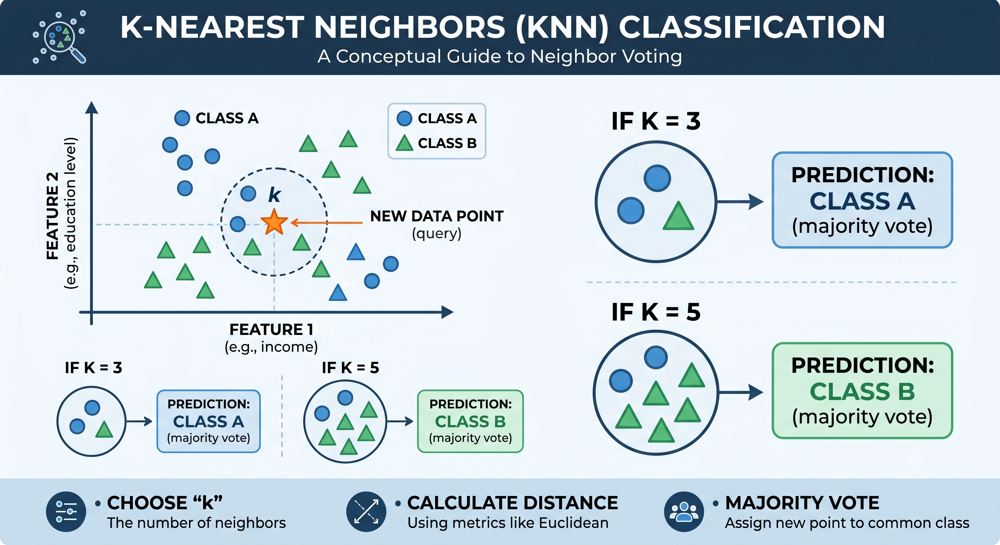

In [3]:
Image("KNN.png")

2. mystery fruit

In [ ]:
import random

# 1. Known fruits: [weight, sweetness, name]
fruits = [
    [150, 8, "watermelon"],
    [160, 9, "watermelon"],
    [50, 2, "apple"],
    [30, 2, "apple"]
]

# 2. Create a mystery fruit
mystery_weight = random.randint(30, 150)
mystery_sweetness = random.randint(2, 10)

print(
    f"Mystery fruit found! Weight: {mystery_weight} g, "
    f"Sweetness: {mystery_sweetness}/10"
)

k = int(input("Please enter K: 1 or 3: "))

# 3. Calculate the distance to every known fruit
scored_fruits = []

for fruit in fruits:
    distance = abs(mystery_weight - fruit[0]) + abs(mystery_sweetness - fruit[1])

    # Save: [distance, fruit name]
    scored_fruits.append([distance, fruit[2]])

# 4. Put the closest fruits first
scored_fruits.sort()

# Pick the first K closest fruits
closest_neighbours = scored_fruits[:k]

# 5. Collect the votes
votes = []

for neighbour in closest_neighbours:
    votes.append(neighbour[1])

print(f"Nearest neighbours: {votes}")

# 6. Count the two types of vote
apple_votes = votes.count("apple")
watermelon_votes = votes.count("watermelon")

print(f"Apple votes: {apple_votes}")
print(f"Watermelon votes: {watermelon_votes}")

# 7. Make the final prediction
if watermelon_votes > apple_votes:
    prediction = "watermelon"
else:
    prediction = "apple"

print(f"Prediction: It is probably a {prediction}!")

Mystery fruit found! Weight: 69 g, Sweetness: 7/10
Nearest neighbours: ['apple', 'apple', 'watermelon']
Apple votes: 2
Watermelon votes: 1
Prediction: It is probably a apple!


In [1]:
# empty[] .append()
even_number = []

for number in range(1,21):
    if number%2 ==0:
        even_number.append(number)
print(even_number)

[2, 4, 6, 8, 10, 12, 14, 16, 18, 20]


In [2]:
# sum
football_scores = [1,3,2,5,2,2,3,5,3]
print(f"The total scores of this football wolrd cup is:{sum(football_scores)}")

The total scores of this football wolrd cup is:26


In [3]:
# sort()
scores = [100,50,70,80,68,75]
scores.sort()
print(scores)

[50, 68, 70, 75, 80, 100]


In [4]:
# sort()
scores = [100,50,70,80,68,75]
scores.sort(reverse=True)
print(scores)

[100, 80, 75, 70, 68, 50]


## Session 2

1. list commands

In [13]:
# empty []
even_numbers = []

for number in range(1,30):
    if number % 2==0:
        even_numbers.append(number)

print(even_numbers)

[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]


In [6]:
# empty []
odd_numbers = []

for number in range(1,30):
    if number % 2==1:
        odd_numbers.append(number)

print(odd_numbers)

[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]


In [5]:
# append[]

scores = []
scores.append(int(input("Please enter a score:")))
scores.append(int(input("Please enter a score:")))
scores.append(int(input("Please enter a score:")))

print(f"All scores:{scores}")
print("Total:",sum(scores))

All scores:[90, 90, 100]
Total: 280


In [15]:
# .sort()
scores = [70,85,45,90,100,60,83]
scores.sort()
print(scores)


[45, 60, 70, 83, 85, 90, 100]


In [16]:
# .sort()
scores = [70,85,45,90,100,60,83]
scores.sort(reverse=True)
print(scores)


[100, 90, 85, 83, 70, 60, 45]


In [17]:
# .count()
fruits = ["apple", "banana", 100,"watermelon","apple","banana",100,True,False]
count_apple = fruits.count("apple")
count_banana = fruits.count("banana")
print(f"The number of apple is :{count_apple}")
print(f"The number of banana is :{count_banana}")


The number of apple is :2
The number of banana is :2


In [3]:
import random
import time

# 1. Known fruits: [weight, sweetness, name]
fruits = [
    [150, 8, "watermelon"],
    [160, 9, "watermelon"],
    [50, 2, "apple"],
    [30, 2, "apple"]
]

# 2. Create a mystery fruit
mystery_weight = random.randint(30, 150)
mystery_sweetness = random.randint(2, 10)
print(f"Mystery fruit found! Weight: {mystery_weight} g, Sweetness: {mystery_sweetness}/10")

k = int(input("Please enter K: 1 or 3: "))

# 3. Calculate the distance to every known fruit
scored_fruits = []
for weight, sweetness, name in fruits:
    distance = abs(mystery_weight - weight) + abs(mystery_sweetness - sweetness)
    scored_fruits.append([distance, name])

# 4. Put the closest fruits first, keep the closest K
scored_fruits.sort()
votes = [name for distance, name in scored_fruits[:k]]
print(f"Nearest neighbours: {votes}")

# 5. Count the two types of vote
apple_votes = votes.count("apple")
watermelon_votes = votes.count("watermelon")
print(f"Apple votes: {apple_votes}, Watermelon votes: {watermelon_votes}")

# 6. Make the final prediction
prediction = "watermelon" if watermelon_votes > apple_votes else "apple"
print(f"Prediction: It is probably a {prediction}!")

# 7. Move the robot based on the prediction
if prediction == "watermelon":
    got.mecanum_move_speed_times(0,30,50,1)   # drive forward
else:
    got.mecanum_move_speed_times(1,30,50,1)

time.sleep(1.5)
got.mecanum_stop()


Mystery fruit found! Weight: 128 g, Sweetness: 7/10
Nearest neighbours: ['watermelon']
Apple votes: 0, Watermelon votes: 1
Prediction: It is probably a watermelon!


In [7]:
import random

taxi_row = 0
taxi_col = 0

passenger_row = random.randint(0, 5)
passenger_col = random.randint(0, 5)

print(f"Drive the taxi from (0,0) to the passenger at ({passenger_row},{passenger_col})")
print("Moves: w=up s=down a=left d=right q=quit")

moves = 0
while (taxi_row, taxi_col) != (passenger_row, passenger_col):
    move = input("Move: ")

    if move == "q":
        print("Game stopped.")
        break
    elif move == "w":
        taxi_row += 1
    elif move == "s":
        taxi_row -= 1
    elif move == "a":
        taxi_col -= 1
    elif move == "d":
        taxi_col += 1

    moves += 1
    distance = abs(taxi_row - passenger_row) + abs(taxi_col - passenger_col)
    print(f"Taxi now at ({taxi_row},{taxi_col}). Distance left: {distance}")

if (taxi_row, taxi_col) == (passenger_row, passenger_col):
    print(f"You reached the passenger in {moves} moves!")
    print("That's the Manhattan distance - blocks driven, no diagonals allowed.")


Drive the taxi from (0,0) to the passenger at (1,4)
Moves: w=up s=down a=left d=right q=quit
Taxi now at (1,0). Distance left: 4
Taxi now at (1,1). Distance left: 3
Taxi now at (1,2). Distance left: 2
Taxi now at (1,3). Distance left: 1
Taxi now at (1,4). Distance left: 0
You reached the passenger in 5 moves!
That's the Manhattan distance - blocks driven, no diagonals allowed.


## Session 3

1.matplotlib commands

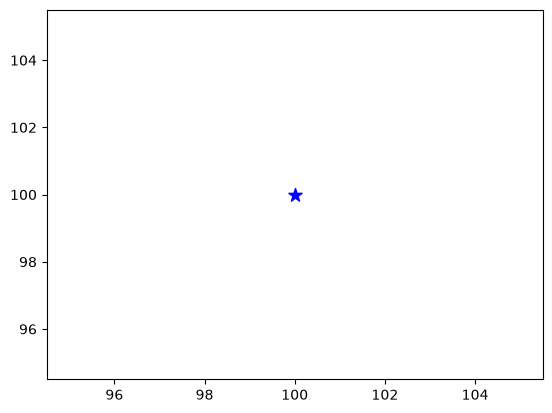

In [6]:
# plt.scatter()
# plt.scatter(x_value,y_value,color = "colour", marker = "shape",s = size)
plt.scatter(100,100,color = "blue",marker = "*",s = 100)

Text(50, 93, '<-----Ryan')

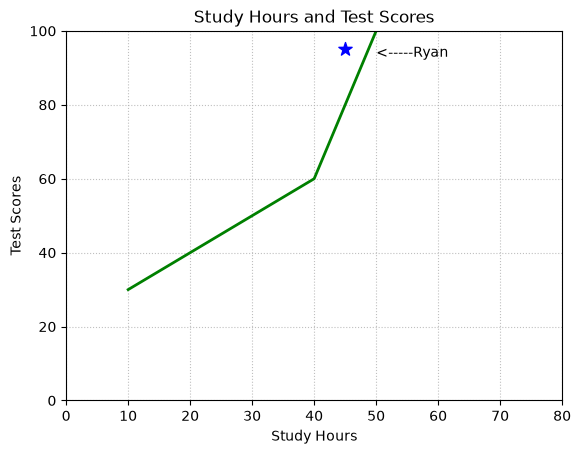

In [36]:
# plt.plot(): plt.plot(x_value,y_value,line_style)
# plt.title(): plt.title("string")
# plt.xlabel(): plt.xlable("string")
# plt.ylabel(): plt.ylable("string")
# plt.xlim(): plt.xlim(int,int)
# plt.ylim(): plt.ylim(int,int)
# plt.grid(): plt.grid(True)/plt.grid(True,linestyle = "line style", alpha = transparency)
# plt.text(): plt.text(int,int,"str")


study_hours = [10,20,30,40,50]
test_scores = [30,40,50,60,100]

plt.plot(study_hours,test_scores,color = "green",linestyle = "-",linewidth = 2)
plt.title("Study Hours and Test Scores")
plt.xlabel("Study Hours")
plt.ylabel("Test Scores")
plt.xlim(0,80)
plt.ylim(0,100)
plt.grid(True,linestyle = ":", alpha =0.8)
plt.scatter(45,95,color = "blue",marker = "*",s = 100)
plt.text(50,93,"<-----Ryan")

## Session 4

1. mystery fruits with matplotlib

Mystery fruit found! Weight: 36 g, Sweetness: 6/10
Nearest neighbours: ['apple', 'apple', 'watermelon']
Apple votes: 2, Watermelon votes: 1
Prediction: It is probably a apple!


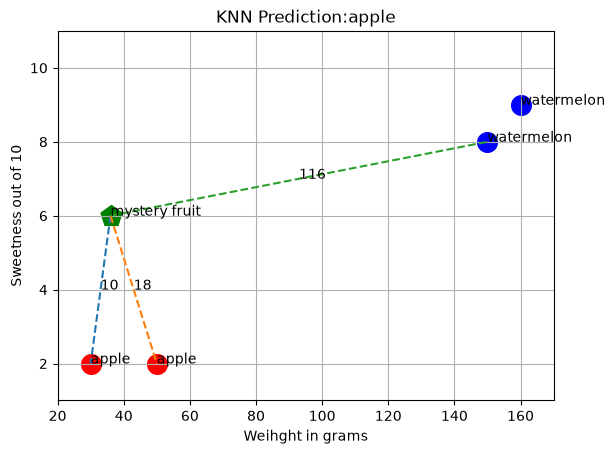

In [4]:
import random
import time
import matplotlib.pyplot as plt

# 1. Known fruits: [weight, sweetness, name]
fruits = [
    [150, 8, "watermelon"],
    [160, 9, "watermelon"],
    [50, 2, "apple"],
    [30, 2, "apple"]
]

# 2. Create a mystery fruit
mystery_weight = random.randint(30, 150)
mystery_sweetness = random.randint(2, 10)
print(f"Mystery fruit found! Weight: {mystery_weight} g, Sweetness: {mystery_sweetness}/10")

k = int(input("Please enter K: 1 or 3: "))

# 3. Calculate the distance to every known fruit
scored_fruits = []
for fruit in fruits:
    weight = fruit[0]
    sweetness = fruit[1]
    name = fruit[2]
    distance = (abs(mystery_weight - weight) + abs(mystery_sweetness - sweetness))
    scored_fruits.append([distance,weight,sweetness,name])

# 4. Put the closest fruits first, keep the closest K
scored_fruits.sort()
closest_neighbours = scored_fruits[:k]

# 5. collect the votes
votes = []

for neighbour in closest_neighbours:
    votes.append(neighbour[3])
print(f"Nearest neighbours: {votes}")

# 6. Count the votes
apple_votes = votes.count("apple")
watermelon_votes = votes.count("watermelon")
print(f"Apple votes: {apple_votes}, Watermelon votes: {watermelon_votes}")

# 7. Make the final prediction
prediction = "watermelon" if watermelon_votes > apple_votes else "apple"
print(f"Prediction: It is probably a {prediction}!")

# 8. draw the known fruits.
for fruit in fruits:
    weight = fruit[0]
    sweetness = fruit[1]
    name = fruit[2]

    if name == "apple":
        fruit_color = "red"
    else:
        fruit_color = "blue"

    plt.scatter(weight,sweetness,color=fruit_color,s = 200)
    plt.text(weight,sweetness,name)

# 9. draw the mystery fruit
plt.scatter(mystery_weight,mystery_sweetness,color="green",marker = "p",s = 250)
plt.text(mystery_weight,mystery_sweetness,"mystery fruit")

# 10. draw lines to the closest neighbours
for neighbour in closest_neighbours:
    distance = neighbour[0]
    weight = neighbour[1]
    sweetness = neighbour[2]

    plt.plot([mystery_weight,weight],[mystery_sweetness,sweetness],linestyle = "--")
    middle_weight = (mystery_weight+ weight)/2
    middle_sweetness = (mystery_sweetness + sweetness)/2

    plt.text(middle_weight,middle_sweetness,str(distance))

# 11. complete the chart
plt.title(f"KNN Prediction:{prediction}")
plt.xlabel("Weihght in grams")
plt.ylabel("Sweetness out of 10")
plt.xlim(20,170)
plt.ylim(1,11)
plt.grid(True)
plt.show()

## Session 5

1. OpenCV and laptop camera

In [ ]:
# take a slefie
import time

# open the laptop camera
camera = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)
time.sleep(1)
print("Camera is ready.")

if camera.isOpened():
    frame_ok,frame = camera.read()

    if frame_ok:
        jpeg_ok,jpeg = cv2.imencode(".jpg",frame)
        if jpeg_ok:
            display(Image(data=jpeg.tobytes()))

else:
    print("The camera is not opened.")

camera.release()


In [ ]:
# take three slefies
import time

# open the laptop camera
camera = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)
time.sleep(1)
print("Camera is ready.")

if not camera.isOpened():
    print("The camera is not working.")
else:
    print("The camera is on.")
    time.sleep(1)

    for i in range(3):
        frame_ok,frame = camera.read()
        if frame_ok:
            jpeg_ok,jpeg = cv2.imencode(".jpg",frame)
            if jpeg_ok:
                display(Image(data=jpeg.tobytes()))
        time.sleep(1)

    camera.release()


2. live video 

In [ ]:
import time

# open the laptop camera
camera = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)
time.sleep(1)
print("Camera is ready.")

if not camera.isOpened():
    print("The camera is not working.")
else:
    print("The camera is on.")
    time.sleep(1)

    handle = None
    start_time = time.time()

    while time.time() - start_time<5:
        frame_ok,frame = camera.read()
        if frame_ok:
            jpeg_ok,jpeg = cv2.imencode(".jpg",frame)
            if jpeg_ok:
                if handle is None: # create the display area for the first frame
                    handle =display(Image(data=jpeg.tobytes()),display_id=True)
                else: # update the same display area
                    handle.update(Image(data=jpeg.tobytes()))
        time.sleep(0.02)

    camera.release()

In [ ]:
# practice

start_time = time.time()
camera.release()
camera = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)
else:
print("The camera is on.")
time.sleep(1)
camera = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)
while time.time()- start_time < 5:
print("The camera is not opened.")
handle = display(Image(data=jpeg.tobytes()),display_id=True)
time.sleep(0.02)
else:
handle.update(Image(data=jpeg.tobytes())) 
if jpeg_ok: # create the display area for the first time
if handle is None:
if frame_ok:
jpeg_ok,jpeg = cv2.imencode(".jpg",frame)
if not camera.isOpened():
handle = None
time.sleep(1)
import time
frame_ok, frame = camera.read()


3. image size

In [ ]:
import time

# open the laptop camera
camera = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)
time.sleep(1)
print("Camera is ready.")

if camera.isOpened():
    frame_ok,frame = camera.read()

    if frame_ok:
        jpeg_ok,jpeg = cv2.imencode(".jpg",frame)
        if jpeg_ok:
            display(Image(data=jpeg.tobytes()))
            print(f"Full shape: {frame.shape}")

            frame_height, frame_width = frame.shape[:2]
            print(f"The height is: {frame_height}")
            print(f"The width is: {frame_width}")

else:
    print("The camera is not opened.")

camera.release()


In [4]:
camera.release()

3.live video with a scanning box

The camera is on.


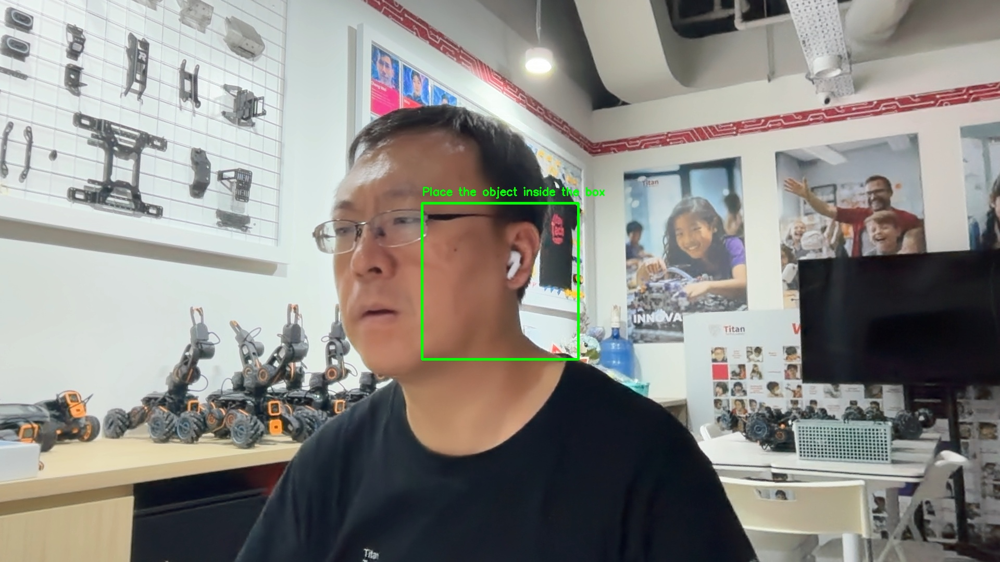

Camera released.


In [1]:
# Live video with a scanning box

import cv2
import time
from IPython.display import display, Image

# Open the laptop camera
camera = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)  # MacBook
# Windows:
# camera = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not camera.isOpened():
    print("The camera is not opened.")

else:
    print("The camera is on.")

    time.sleep(1)

    handle = None
    start_time = time.time()

    while time.time() - start_time < 15:

        # Capture one frame
        frame_ok, frame = camera.read()

        if frame_ok:

            # Get the frame size
            frame_height, frame_width = frame.shape[:2]

            # Set the scanning-box size
            box_width = 300
            box_height = 300

            # Calculate the top-left corner
            x1 = (frame_width - box_width) // 2
            y1 = (frame_height - box_height) // 2

            # Calculate the bottom-right corner
            x2 = x1 + box_width
            y2 = y1 + box_height

            # Draw the green scanning box
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                3
            )

            # Add instructions above the box
            cv2.putText(
                frame,
                "Place the object inside the box",
                (x1, y1 - 15),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

            # Convert the frame to JPEG
            jpeg_ok, jpeg = cv2.imencode(".jpg", frame)

            if jpeg_ok:

                # Create the display area for the first frame
                if handle is None:
                    handle = display(
                        Image(data=jpeg.tobytes()),
                        display_id=True
                    )

                # Update the same display area
                else:
                    handle.update(
                        Image(data=jpeg.tobytes())
                    )

        time.sleep(0.03)

    camera.release()
    print("Camera released.")

## Session 7

1.create folders to store the images

In [3]:
import os

# Create Main dataset folder
DATASET_FOLDER = "traffic_sign_dataset"

In [4]:
# Create LEFT_FOLDER path
DATASET_FOLDER = "traffic_sign_dataset"
LEFT_FOLDER=os.path.join(DATASET_FOLDER,"LEFT")

# Create the real folder
os.makedirs(LEFT_FOLDER,exist_ok=True)

In [2]:
import os

# Main dataset folder
DATASET_FOLDER = "traffic_sign_dataset"

# Four class folders
LEFT_FOLDER = os.path.join(DATASET_FOLDER, "LEFT")
RIGHT_FOLDER = os.path.join(DATASET_FOLDER, "RIGHT")
STOP_FOLDER = os.path.join(DATASET_FOLDER, "STOP")
NO_SIGN_FOLDER = os.path.join(DATASET_FOLDER, "NO_SIGN")

# Create the folders
os.makedirs(LEFT_FOLDER, exist_ok=True)
os.makedirs(RIGHT_FOLDER, exist_ok=True)
os.makedirs(STOP_FOLDER, exist_ok=True)
os.makedirs(NO_SIGN_FOLDER, exist_ok=True)

print("Dataset folders are ready.")

Dataset folders are ready.


2. collect the images

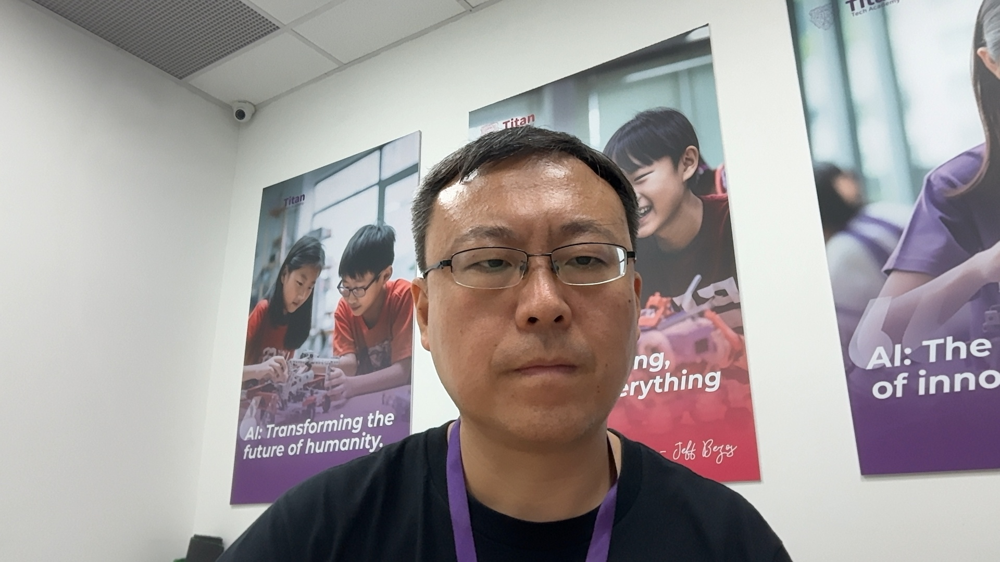

Full shape: (1080, 1920, 3)
Height: 1080
Width: 1920


In [1]:
# frame.shape
import cv2
import time
from IPython.display import display, Image

camera = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)
time.sleep(1)

if camera.isOpened():
    frame_ok, frame = camera.read()

    if frame_ok:
        jpeg_ok, jpeg = cv2.imencode(".jpg", frame)

        if jpeg_ok:
            display(Image(data=jpeg.tobytes()))
            print("Full shape:", frame.shape)

            frame_height, frame_width = frame.shape[:2]
            print("Height:", frame_height)
            print("Width:", frame_width)
else:
    print("The camera could not be opened.")

camera.release()

In [ ]:
import cv2
import time
import os
from IPython.display import display, Image


# Choose which category to collect
save_folder = LEFT_FOLDER
class_name = "LEFT"

total_images = 30
save_interval = 1


# Open the MacBook camera
camera = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)

# Windows:
# camera = cv2.VideoCapture(0, cv2.CAP_DSHOW)


if not camera.isOpened():
    print("The camera could not be opened.")

else:
    print(f"Collecting {class_name} images.")
    print("Place the sign inside the green box.")

    time.sleep(5)

    collected = 0
    last_save_time = 0
    handle = None

    while collected < total_images:

        frame_ok, frame = camera.read()

        if not frame_ok:
            print("The camera could not capture an image.")
            break

        # Get the frame size
        frame_height, frame_width = frame.shape[:2]

        # Create a 300 × 300 box in the centre
        box_size = 300

        x1 = (frame_width - box_size) // 2
        y1 = (frame_height - box_size) // 2
        x2 = x1 + box_size
        y2 = y1 + box_size

        # Crop the image inside the box
        scanning_area = frame[y1:y2, x1:x2] # collect images before drawing the green box command below to prevent to collecting the green box.

        current_time = time.time()

        # Save one image every 1 second
        if current_time - last_save_time >= save_interval:

            filename = os.path.join(
                save_folder,
                f"{class_name.lower()}_{collected}.jpg"
            )

            saved_ok = cv2.imwrite(filename, scanning_area)

            if saved_ok:
                collected += 1
                last_save_time = current_time
                print(f"Saved image {collected}")

        # Draw the green scanning box
        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            3
        )

        # Show the number of collected images
        cv2.putText(
            frame,
            f"{class_name}: {collected}/{total_images}",
            (x1, y1 - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

        # Show the live video in Jupyter Notebook
        jpeg_ok, jpeg = cv2.imencode(".jpg", frame)

        if jpeg_ok:

            if handle is None:
                handle = display(
                    Image(data=jpeg.tobytes()),
                    display_id=True
                )

            else:
                handle.update(
                    Image(data=jpeg.tobytes())
                )

        time.sleep(0.03)

    camera.release()

    print(f"Finished collecting {collected} {class_name} images.")
    print("Camera released.")

In [ ]:
import cv2
import time
import os
import glob
from IPython.display import display, Image


def collect_images(class_name, save_folder, total_images=30):

    save_interval = 1

    # Open the MacBook camera
    camera = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)

    # Windows:
    # camera = cv2.VideoCapture(0, cv2.CAP_DSHOW)

    if not camera.isOpened():
        print("The camera could not be opened.")
        camera.release()
        return

    # Start counting from the images that are already saved, so running this
    # again ADDS new images instead of writing over the old ones.
    # This is what makes it possible to collect 10 images from one sign
    # picture, change the picture, and collect 10 more.
    collected = len(glob.glob(os.path.join(save_folder, "*.jpg")))
    target = collected + total_images

    print(f"Collecting {class_name} images.")
    print(f"The folder already has {collected} images.")
    print("Place the sign inside the green box.")

    time.sleep(3)

    last_save_time = 0
    failed_saves = 0
    handle = None

    while collected < target:

        frame_ok, frame = camera.read()

        if not frame_ok:
            print("The camera could not capture an image.")
            break

        # Get the frame size
        frame_height, frame_width = frame.shape[:2]

        # Create a 300 x 300 box in the centre.
        # The camera records at 1920 x 1080, so this box covers about one
        # sixth of the width. Every training image is cropped at this size.
        box_size = 300

        x1 = (frame_width - box_size) // 2
        y1 = (frame_height - box_size) // 2
        x2 = x1 + box_size
        y2 = y1 + box_size

        # Crop the image inside the box BEFORE the green box is drawn,
        # so the green box is never saved into the training picture
        scanning_area = frame[y1:y2, x1:x2]

        current_time = time.time()

        # Save one image every 1 second
        if current_time - last_save_time >= save_interval:

            filename = os.path.join(
                save_folder,
                f"{class_name.lower()}_{collected}.jpg"
            )

            saved_ok = cv2.imwrite(filename, scanning_area)

            if saved_ok:
                collected += 1
                last_save_time = current_time
                failed_saves = 0
                print(f"Saved image {collected}")

            else:
                # Give up instead of looping forever if the file cannot be saved
                failed_saves += 1
                last_save_time = current_time
                print("The image could not be saved.")

                if failed_saves >= 3:
                    print("Saving keeps failing. Check the folder, then try again.")
                    break

        # Draw the green scanning box
        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            3
        )

        # Show the number of collected images
        cv2.putText(
            frame,
            f"{class_name}: {collected}/{target}",
            (x1, y1 - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

        # Show the live video in Jupyter Notebook
        jpeg_ok, jpeg = cv2.imencode(".jpg", frame)

        if jpeg_ok:

            if handle is None:
                handle = display(
                    Image(data=jpeg.tobytes()),
                    display_id=True
                )

            else:
                handle.update(
                    Image(data=jpeg.tobytes())
                )

        time.sleep(0.03)

    camera.release()

    print(f"Finished. The folder now has {collected} {class_name} images.")
    print("Camera released.")

Place the sign inside the green box.
Saved image 1


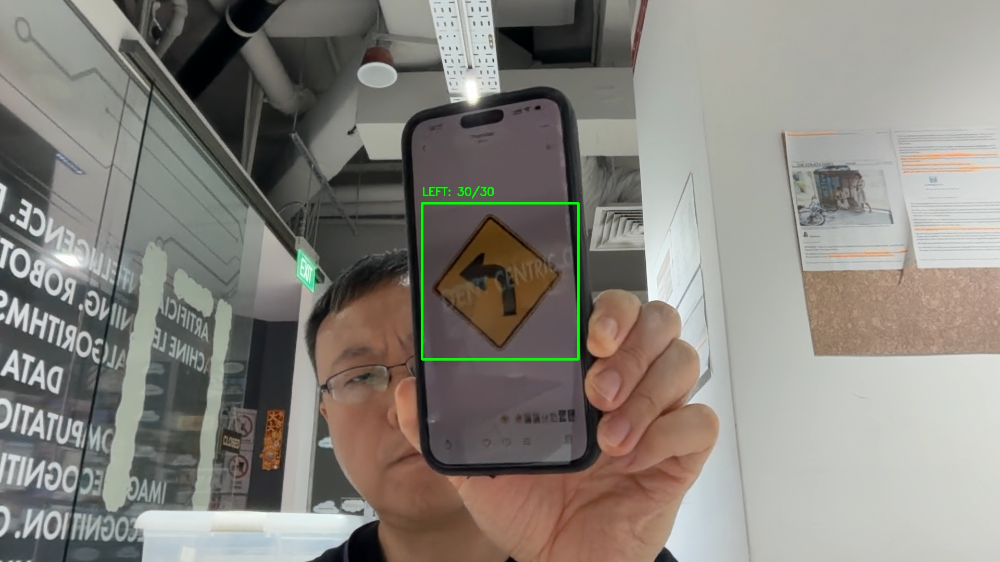

Saved image 2
Saved image 3
Saved image 4
Saved image 5
Saved image 6
Saved image 7
Saved image 8
Saved image 9
Saved image 10
Saved image 11
Saved image 12
Saved image 13
Saved image 14
Saved image 15
Saved image 16
Saved image 17
Saved image 18
Saved image 19
Saved image 20
Saved image 21
Saved image 22
Saved image 23
Saved image 24
Saved image 25
Saved image 26
Saved image 27
Saved image 28
Saved image 29
Saved image 30
Finished collecting 30 LEFT images.
Camera released.


30

In [9]:
collect_images("LEFT", LEFT_FOLDER, total_images=30)

Place the sign inside the green box.
Saved image 1


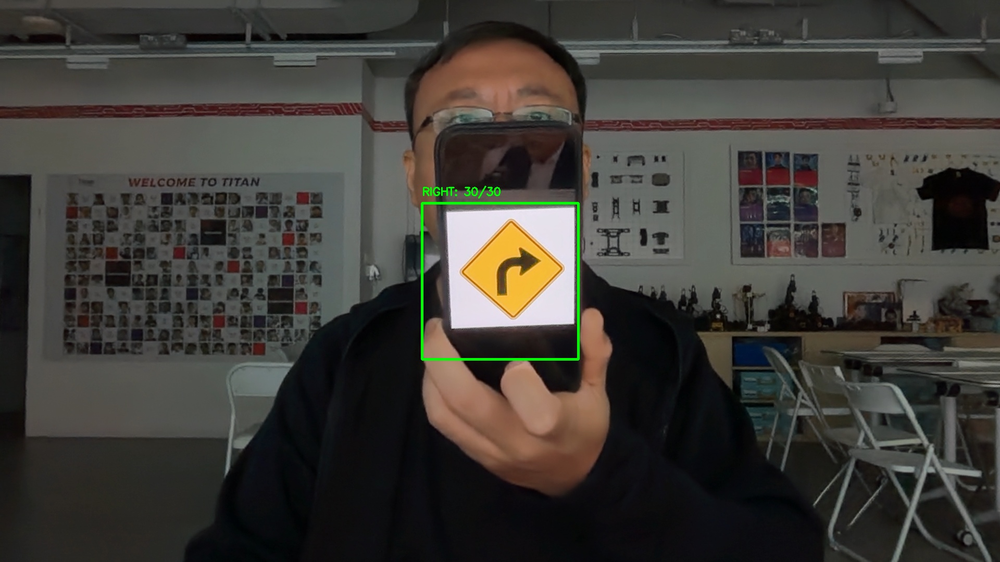

Saved image 2
Saved image 3
Saved image 4
Saved image 5
Saved image 6
Saved image 7
Saved image 8
Saved image 9
Saved image 10
Saved image 11
Saved image 12
Saved image 13
Saved image 14
Saved image 15
Saved image 16
Saved image 17
Saved image 18
Saved image 19
Saved image 20
Saved image 21
Saved image 22
Saved image 23
Saved image 24
Saved image 25
Saved image 26
Saved image 27
Saved image 28
Saved image 29
Saved image 30
Finished collecting 30 RIGHT images.
Camera released.


In [6]:
collect_images("RIGHT", RIGHT_FOLDER, total_images=30)

Place the sign inside the green box.
Saved image 1


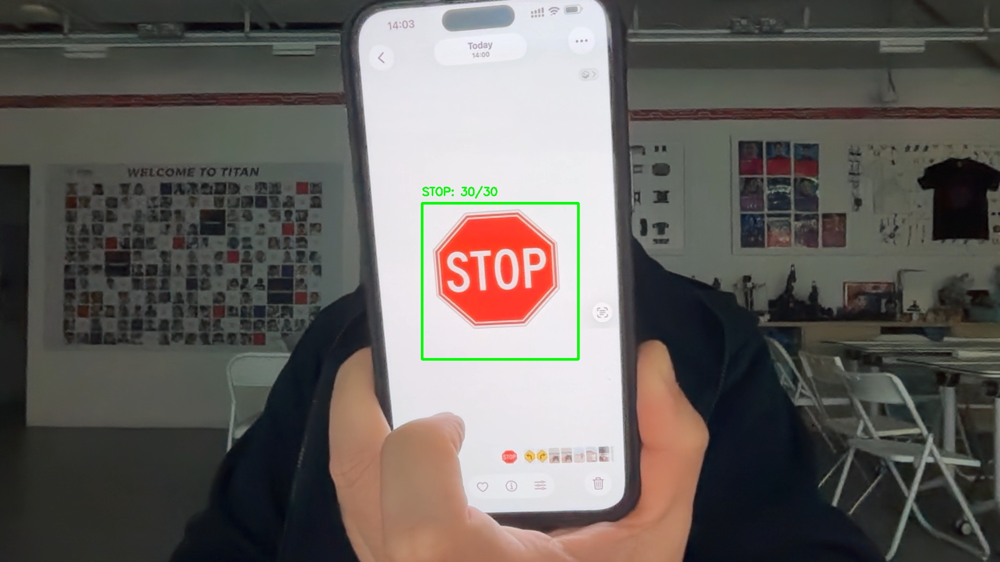

Saved image 2
Saved image 3
Saved image 4
Saved image 5
Saved image 6
Saved image 7
Saved image 8
Saved image 9
Saved image 10
Saved image 11
Saved image 12
Saved image 13
Saved image 14
Saved image 15
Saved image 16
Saved image 17
Saved image 18
Saved image 19
Saved image 20
Saved image 21
Saved image 22
Saved image 23
Saved image 24
Saved image 25
Saved image 26
Saved image 27
Saved image 28
Saved image 29
Saved image 30
Finished collecting 30 STOP images.
Camera released.


In [9]:
collect_images("STOP", STOP_FOLDER, total_images=30)

Place the sign inside the green box.
Saved image 1


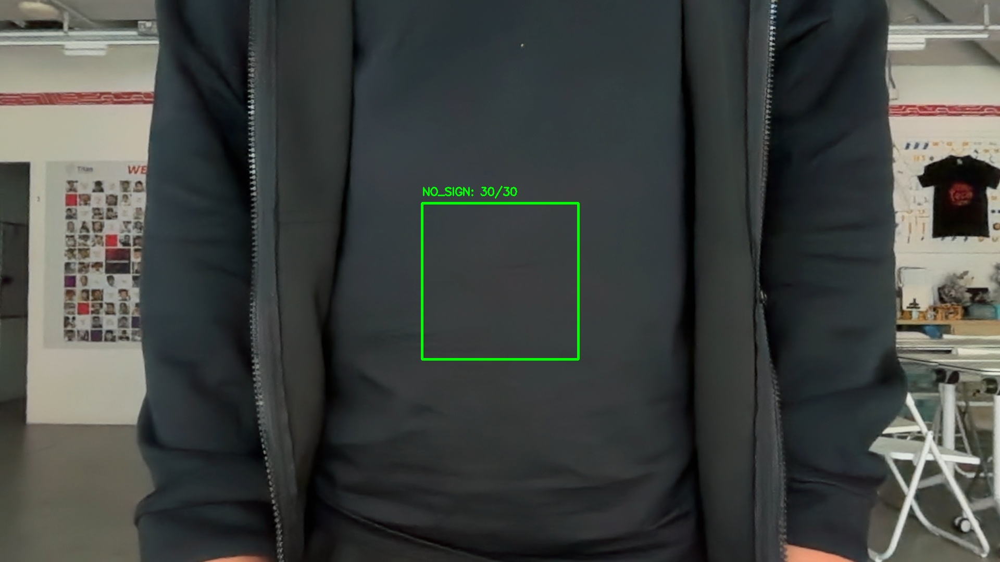

Saved image 2
Saved image 3
Saved image 4
Saved image 5
Saved image 6
Saved image 7
Saved image 8
Saved image 9
Saved image 10
Saved image 11
Saved image 12
Saved image 13
Saved image 14
Saved image 15
Saved image 16
Saved image 17
Saved image 18
Saved image 19
Saved image 20
Saved image 21
Saved image 22
Saved image 23
Saved image 24
Saved image 25
Saved image 26
Saved image 27
Saved image 28
Saved image 29
Saved image 30
Finished collecting 30 NO_SIGN images.
Camera released.


In [11]:
collect_images("NO_SIGN", NO_SIGN_FOLDER, total_images=30)

3. check the data set

In [3]:
import glob

left_images = glob.glob(LEFT_FOLDER + "/*.jpg")
right_images = glob.glob(RIGHT_FOLDER + "/*.jpg")
stop_images = glob.glob(STOP_FOLDER + "/*.jpg")
no_sign_images = glob.glob(NO_SIGN_FOLDER + "/*.jpg")

print(f"LEFT: {len(left_images)}")
print(f"RIGHT: {len(right_images)}")
print(f"STOP: {len(stop_images)}")
print(f"NO_SIGN: {len(no_sign_images)}")

LEFT: 30
RIGHT: 30
STOP: 30
NO_SIGN: 30


In [4]:
minimum_images = 28

dataset_ready = True

if len(left_images) < minimum_images:
    print("LEFT needs more images.")
    dataset_ready = False

if len(right_images) < minimum_images:
    print("RIGHT needs more images.")
    dataset_ready = False

if len(stop_images) < minimum_images:
    print("STOP needs more images.")
    dataset_ready = False

if len(no_sign_images) < minimum_images:
    print("NO_SIGN needs more images.")
    dataset_ready = False

if dataset_ready:
    print("The dataset is ready for training.")
else:
    print("Please collect more images before training.")

The dataset is ready for training.


4. Turn one picture into KNN numbers

In [5]:
import cv2
import numpy as np
import glob
import os
import time
from IPython.display import display, Image

# The size KNN will use for every picture
IMAGE_SIZE = 32

# How many neighbours are allowed to vote
K = 3

# This MUST be the same box size used when the images were collected.
#
# WARNING: the camera records at 1920 x 1080 and every training image was
# cropped from a 300 x 300 box at that resolution. Do NOT set the camera to
# a smaller resolution. The box would then cover a much larger part of the
# view, the sign would fill a different fraction of the crop, and every
# training image would have to be collected again.
BOX_SIZE = 300


def prepare_image(image):
    # Step 1: Change the image to grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Step 2: Make every image 32 x 32
    small_image = cv2.resize(
        gray,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    # Step 3: Change the square into one long row
    pixel_row = small_image.flatten()

    # Step 4: Change the numbers to float32
    pixel_row = pixel_row.astype(
        np.float32
    )

    # Step 5: Change 0-255 into 0-1
    pixel_row = pixel_row / 255.0

    return pixel_row


print("prepare_image is ready.")
print("Every picture will become", IMAGE_SIZE * IMAGE_SIZE, "numbers.")

prepare_image is ready.
Every picture will become 1024 numbers.


The computer cannot see. It can only work with numbers, so every picture must be turned into the same kind of numbers before KNN can compare them.

Because 32 x 32 is 1024, every picture becomes one row of exactly 1024 numbers.

`BOX_SIZE` matters here. The training images were cropped from a 300 x 300 box, so the live camera must use a 300 x 300 box as well. If the two boxes are different sizes, the live pictures will not match the training pictures and the answers will be wrong.

5. Load the training images

In [6]:
if not dataset_ready:
    print("The dataset is not ready. Collect more images first.")

else:
    training_data = []
    training_labels = []

    # LEFT = 0
    for filename in glob.glob(os.path.join(LEFT_FOLDER, "*.jpg")):
        image = cv2.imread(filename)

        if image is not None:
            training_data.append(prepare_image(image))
            training_labels.append(0)

    # RIGHT = 1
    for filename in glob.glob(os.path.join(RIGHT_FOLDER, "*.jpg")):
        image = cv2.imread(filename)

        if image is not None:
            training_data.append(prepare_image(image))
            training_labels.append(1)

    # STOP = 2
    for filename in glob.glob(os.path.join(STOP_FOLDER, "*.jpg")):
        image = cv2.imread(filename)

        if image is not None:
            training_data.append(prepare_image(image))
            training_labels.append(2)

    # NO_SIGN = 3
    for filename in glob.glob(os.path.join(NO_SIGN_FOLDER, "*.jpg")):
        image = cv2.imread(filename)

        if image is not None:
            training_data.append(prepare_image(image))
            training_labels.append(3)

    # Change the Python lists into NumPy arrays for OpenCV
    training_data = np.array(
        training_data,
        dtype=np.float32
    )

    training_labels = np.array(
        training_labels,
        dtype=np.float32
    ).reshape(-1, 1)

    print("Training data shape  :", training_data.shape)
    print("Training labels shape:", training_labels.shape)

Training data shape  : (120, 1024)
Training labels shape: (120, 1)


The labels are:

```text
0 = LEFT
1 = RIGHT
2 = STOP
3 = NO_SIGN
```

With 30 images in each of the four folders, the training data shape should be `(120, 1024)`. That means 120 example pictures, and 1024 pixel numbers for each one.

Notice the two lines inside every loop. `cv2.imread(filename)` turns a filename, which is only text, into a real picture. `prepare_image(image)` then receives that real picture. A filename on its own cannot be given to `prepare_image`.

6. Train the KNN model

In [7]:
knn = cv2.ml.KNearest_create()

knn.train(
    training_data,
    cv2.ml.ROW_SAMPLE,
    training_labels
)

print("KNN training is complete.")

KNN training is complete.


7. Predict one picture

In [8]:
def predict_sign(image):
    pixel_row = prepare_image(image)

    # OpenCV wants one sample row
    pixel_row = pixel_row.reshape(1, -1)

    _, result, neighbours, distances = knn.findNearest(
        pixel_row,
        K
    )

    label = int(result[0][0])

    if label == 0:
        prediction = "LEFT"

    elif label == 1:
        prediction = "RIGHT"

    elif label == 2:
        prediction = "STOP"

    else:
        prediction = "NO_SIGN"

    return prediction


print("predict_sign is ready.")

predict_sign is ready.


8. KNN test without the UGOT

Show a sign to the camera.
Show STOP to finish, or wait 60 seconds.
Hold the sign steady


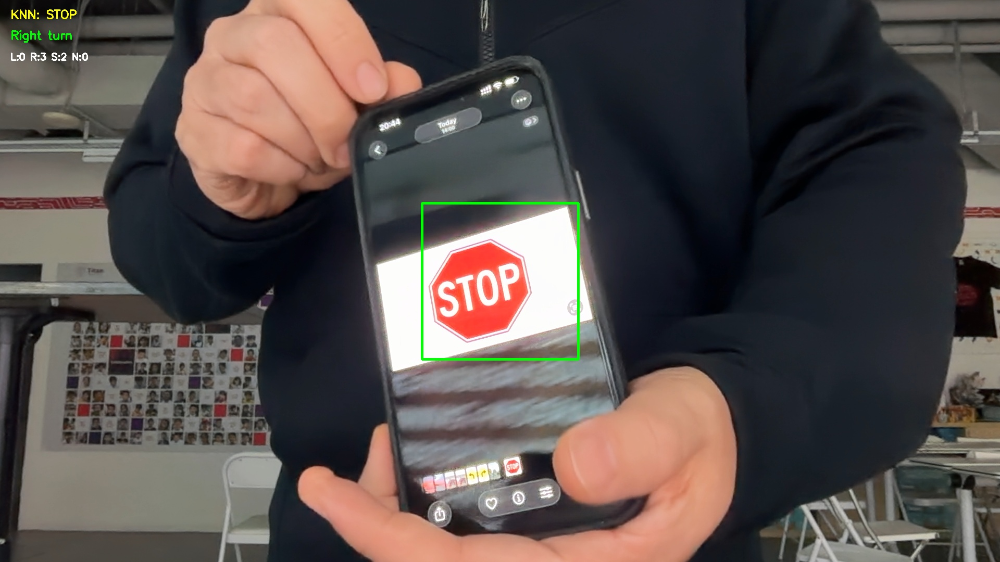

Moving forward
Left turn
Right turn
Left turn
Right turn
Left turn
Moving forward
Left turn
Right turn
Hold the sign steady
Moving forward
Left turn
Right turn
Left turn
Right turn
Left turn
Right turn
Left turn
Right turn
Left turn
Moving forward
Left turn
Right turn
Left turn
Right turn
Left turn
Right turn
Left turn
Right turn
STOP sign recognised. The test is finished.
Camera released.


In [20]:
# TEST VERSION - no robot, no try/except.
# Run sections 4 to 7 first.

import cv2
import time
from IPython.display import display, Image

# The test stops by itself after this many seconds
MAX_SECONDS = 60

# Open the MacBook camera
camera = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)

# Windows:
# camera = cv2.VideoCapture(0, cv2.CAP_DSHOW)

# Do NOT set the camera resolution here. See the warning in section 4.

prediction_history = []
handle = None

last_action = None
message = "Hold the sign steady"

if not camera.isOpened():
    print("The camera could not be opened.")

else:
    print("Show a sign to the camera.")
    print("Show STOP to finish, or wait", MAX_SECONDS, "seconds.")

    start_time = time.time()

    while time.time() - start_time < MAX_SECONDS:

        frame_ok, frame = camera.read()

        if not frame_ok:
            print("The camera could not capture an image.")
            break

        # Build the same 300 x 300 box used during collection
        frame_height, frame_width = frame.shape[:2]

        x1 = (frame_width - BOX_SIZE) // 2
        y1 = (frame_height - BOX_SIZE) // 2
        x2 = x1 + BOX_SIZE
        y2 = y1 + BOX_SIZE

        # Crop before drawing the green box
        scanning_area = frame[y1:y2, x1:x2]

        # Ask KNN about this one frame
        prediction = predict_sign(scanning_area)

        # Keep only the latest 5 predictions
        prediction_history.append(prediction)

        if len(prediction_history) > 5:
            prediction_history.pop(0)

        # Count the votes
        left_votes = prediction_history.count("LEFT")
        right_votes = prediction_history.count("RIGHT")
        stop_votes = prediction_history.count("STOP")
        no_sign_votes = prediction_history.count("NO_SIGN")

        # A result needs at least 3 votes out of 5
        stable_result = "WAITING"

        if left_votes >= 3:
            stable_result = "LEFT"

        elif right_votes >= 3:
            stable_result = "RIGHT"

        elif stop_votes >= 3:
            stable_result = "STOP"

        elif no_sign_votes >= 3:
            stable_result = "NO_SIGN"

        # The STOP sign ends the test
        if stable_result == "STOP":
            print("STOP sign recognised. The test is finished.")
            break

        # Print the message only when the action changes
        if stable_result != last_action:

            if stable_result == "LEFT":
                message = "Left turn"

            elif stable_result == "RIGHT":
                message = "Right turn"

            elif stable_result == "NO_SIGN":
                message = "Moving forward"

            else:
                message = "Hold the sign steady"

            print(message)
            last_action = stable_result

        # Draw the green box, the messages and the vote counts
        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            3
        )

        cv2.putText(
            frame,
            f"KNN: {prediction}",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            (0, 255, 255),
            2
        )

        cv2.putText(
            frame,
            message,
            (20, 75),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            (0, 255, 0),
            2
        )

        cv2.putText(
            frame,
            f"L:{left_votes} R:{right_votes} S:{stop_votes} N:{no_sign_votes}",
            (20, 115),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2
        )

        # Show the live video in Jupyter Notebook
        jpeg_ok, jpeg = cv2.imencode(".jpg", frame)

        if jpeg_ok:

            if handle is None:
                handle = display(
                    Image(data=jpeg.tobytes()),
                    display_id=True
                )

            else:
                handle.update(
                    Image(data=jpeg.tobytes())
                )

        time.sleep(0.03)

camera.release()
print("Camera released.")

9. Decide what the UGOT should do

In [9]:
# Rotation speed, degrees per second, allowed range 5 to 280
TURN_SPEED = 20

# Forward speed, centimetres per second, allowed range 5 to 80
FORWARD_SPEED = 15


def do_action(stable_result):
    if stable_result == "LEFT":
        # 2 means turn left
        got.mecanum_turn_speed(2, TURN_SPEED)
        return "ACTION: TURN LEFT"

    elif stable_result == "RIGHT":
        # 3 means turn right
        got.mecanum_turn_speed(3, TURN_SPEED)
        return "ACTION: TURN RIGHT"

    elif stable_result == "NO_SIGN":
        # 0 means forward
        got.mecanum_move_speed(0, FORWARD_SPEED)
        return "ACTION: FORWARD"

    else:
        # Not sure yet, so do not move
        got.mecanum_stop()
        return "HOLD THE SIGN STEADY"


print("do_action is ready.")

do_action is ready.


The four signs give the vehicle four different jobs.

A LEFT sign rotates the vehicle anti-clockwise on the spot, and a RIGHT sign rotates it clockwise. The vehicle keeps rotating for as long as the sign is held up. When no sign is shown, the vehicle drives forward. When the STOP sign is shown, the vehicle stops and the program finishes.

Because NO_SIGN means forward, the vehicle will start driving as soon as the next cell runs and nothing is being held in front of the camera. Place the robot on the floor with space in front of it, and be ready to show a sign or press the interrupt button.

10. Live recognition and robot control

In [ ]:
# Open the MacBook camera
camera = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)

# Windows:
# camera = cv2.VideoCapture(0, cv2.CAP_DSHOW)

# Do NOT set the camera resolution here. See the warning in section 4.

prediction_history = []
handle = None

# Remember the last command sent to the robot
last_action = None
message = "HOLD THE SIGN STEADY"

if not camera.isOpened():
    print("The camera could not be opened.")
    camera.release()

else:
    print("Place the robot on the floor with space in front of it.")

    for number in range(3, 0, -1):
        print(number)
        time.sleep(1)

    print("Started. Show the STOP sign to finish.")

    try:
        while True:

            frame_ok, frame = camera.read()

            if not frame_ok:
                print("The camera could not capture an image.")
                break

            # Build the same 300 x 300 box used during collection
            frame_height, frame_width = frame.shape[:2]

            x1 = (frame_width - BOX_SIZE) // 2
            y1 = (frame_height - BOX_SIZE) // 2
            x2 = x1 + BOX_SIZE
            y2 = y1 + BOX_SIZE

            # Crop before drawing the green box, so the box is not in the picture
            scanning_area = frame[y1:y2, x1:x2]

            # Ask KNN about this one frame
            prediction = predict_sign(scanning_area)

            # Keep only the latest 5 predictions
            prediction_history.append(prediction)

            if len(prediction_history) > 5:
                prediction_history.pop(0)

            # Count the votes
            left_votes = prediction_history.count("LEFT")
            right_votes = prediction_history.count("RIGHT")
            stop_votes = prediction_history.count("STOP")
            no_sign_votes = prediction_history.count("NO_SIGN")

            # A result needs at least 3 votes out of 5
            stable_result = "WAITING"

            if left_votes >= 3:
                stable_result = "LEFT"

            elif right_votes >= 3:
                stable_result = "RIGHT"

            elif stop_votes >= 3:
                stable_result = "STOP"

            elif no_sign_votes >= 3:
                stable_result = "NO_SIGN"

            # The STOP sign ends the whole program
            if stable_result == "STOP":
                got.mecanum_stop()
                print("STOP sign recognised. The program is finished.")
                got.play_audio_tts("Stop sign detected. Mission complete.", 0, False)
                break

            # Only send a command when the action CHANGES.
            # The UGOT keeps doing the last thing it was told, so sending the
            # same command on every frame would flood the robot with messages.
            if stable_result != last_action:
                message = do_action(stable_result)
                last_action = stable_result

            # Draw the green box and the two messages
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                3
            )

            cv2.putText(
                frame,
                f"KNN: {prediction}",
                (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.75,
                (0, 255, 255),
                2
            )

            cv2.putText(
                frame,
                message,
                (20, 75),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.75,
                (0, 255, 0),
                2
            )

            # Show the live video in Jupyter Notebook
            jpeg_ok, jpeg = cv2.imencode(".jpg", frame)

            if jpeg_ok:

                if handle is None:
                    handle = display(
                        Image(data=jpeg.tobytes()),
                        display_id=True
                    )

                else:
                    handle.update(
                        Image(data=jpeg.tobytes())
                    )

            time.sleep(0.03)

    except KeyboardInterrupt:
        print("Stopped by hand.")

    finally:
        got.mecanum_stop()
        camera.release()
        print("The wheels are stopped and the camera is released.")

How to run this project

Run the cells in order. Sections 4 to 7 teach the laptop to recognise the signs, section 8 decides what the vehicle should do, and section 9 joins them together.

The two screens work as a pair. `KNN:` on the top line is the answer for the single frame the laptop is looking at right now, and it will flicker. The green line underneath is the stable answer, which only changes after 3 of the last 5 frames agree. The vehicle obeys the green line, never the flickering one, so one bad frame cannot send the robot the wrong way.

The `finally` block is the safety net. Whether the program ends because of the STOP sign, because you pressed the interrupt button, or because something went wrong, the wheels are always stopped and the camera is always released.

If the robot behaves strangely, the usual cause is the dataset rather than the code. Check that the green box in section 9 is the same size as the box used for collection, that the room lighting has not changed since the images were collected, and that the NO_SIGN folder contains genuinely empty views. If the vehicle keeps drifting forward when a sign is held up, the sign is probably not filling enough of the green box, so hold it closer.